# House Price Prediction — Proiect Complet de Regresie

## 1. Definirea Problemei

### Problema abordată
Acest proiect abordează o **problemă de regresie supervisată**: predicția prețului unei locuințe pe baza caracteristicilor sale fizice și contextuale. Modelul va învăța relația dintre atributele unei proprietăți (suprafață, număr de camere, dimensiunea lotului, calitatea vecinătății etc.) și prețul de vânzare al acesteia.

### Variabila țintă (de ieșire)
- **`House_Price`** — prețul de vânzare al locuinței
- **Unitate de măsură**: unități monetare (USD)
- **Semnificație practică**: reprezintă valoarea de piață a proprietății
- **Interval de valori**: va fi determinat în secțiunea EDA

### Variabilele de intrare (features)
| Variabilă | Tip | Descriere |
|-----------|-----|-----------|
| `Square_Footage` | Numerică continuă | Suprafața locuinței (sq ft) |
| `Num_Bedrooms` | Numerică discretă | Numărul de dormitoare |
| `Num_Bathrooms` | Numerică discretă | Numărul de băi |
| `Year_Built` | Numerică discretă | Anul construcției |
| `Lot_Size` | Numerică continuă | Dimensiunea lotului de teren (acres) |
| `Garage_Size` | Numerică discretă | Capacitatea garajului (0, 1 sau 2 mașini) |
| `Neighborhood_Quality` | Numerică discretă | Calitatea vecinătății (scor 1-10) |


## 2. Importarea Bibliotecilor

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

import shap

from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

## 3. Privire generală asupra datelor

In [21]:
df = pd.read_csv('house_price_regression_dataset.csv')
print("Forma setului de date:", df.shape)
df.head()

Forma setului de date: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [22]:
print("Tipurile de date:")
print(df.dtypes)
print("\nNumăr de valori lipsă pe coloană:")
print(df.isna().sum())
print("\nStatistici descriptive:")
df.describe()

Tipurile de date:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

Număr de valori lipsă pe coloană:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Statistici descriptive:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [23]:
print(f"Rânduri duplicate: {df.duplicated().sum()}")
print(f"Coloane: {list(df.columns)}")

Rânduri duplicate: 0
Coloane: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']


## 4. Analiza exploratorie a datelor (EDA)
Vom explora:
- distribuția variabilei țintă;
- distribuția caracteristicilor numerice;
- relațiile dintre caracteristici și preț;
- corelațiile numerice.

### 4.1 Distribuția variabilei țintă

Histograma și boxplot-ul ne arată cum sunt distribuite prețurile.

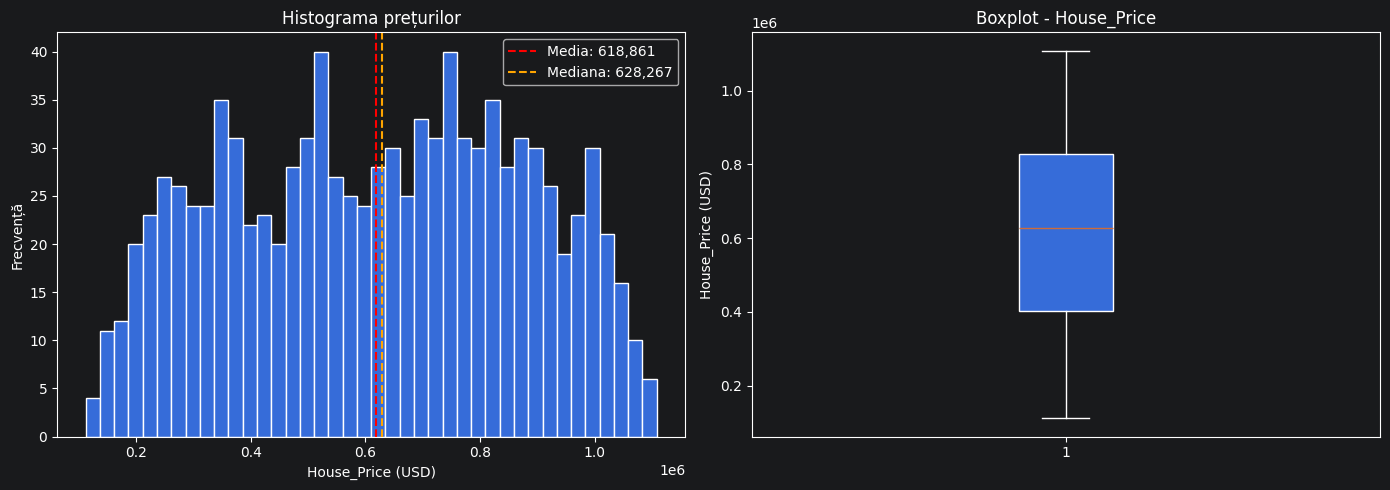

Media: 618,861.02
Mediana: 628,267.29
Skewness: -0.0640


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['House_Price'], bins=40, edgecolor='white')
axes[0].set_title('Histograma prețurilor')
axes[0].set_xlabel('House_Price (USD)')
axes[0].set_ylabel('Frecvență')
axes[0].axvline(df['House_Price'].mean(), color='red', linestyle='--', label=f"Media: {df['House_Price'].mean():,.0f}")
axes[0].axvline(df['House_Price'].median(), color='orange', linestyle='--', label=f"Mediana: {df['House_Price'].median():,.0f}")
axes[0].legend()

axes[1].boxplot(df['House_Price'], vert=True, patch_artist=True)
axes[1].set_title('Boxplot - House_Price')
axes[1].set_ylabel('House_Price (USD)')

plt.tight_layout()
plt.show()

print(f"Media: {df['House_Price'].mean():,.2f}")
print(f"Mediana: {df['House_Price'].median():,.2f}")
print(f"Skewness: {df['House_Price'].skew():.4f}")

### 4.2 Histograme pentru caracteristicile numerice

Histogramele arată cum sunt distribuite valorile fiecărei caracteristici numerice.


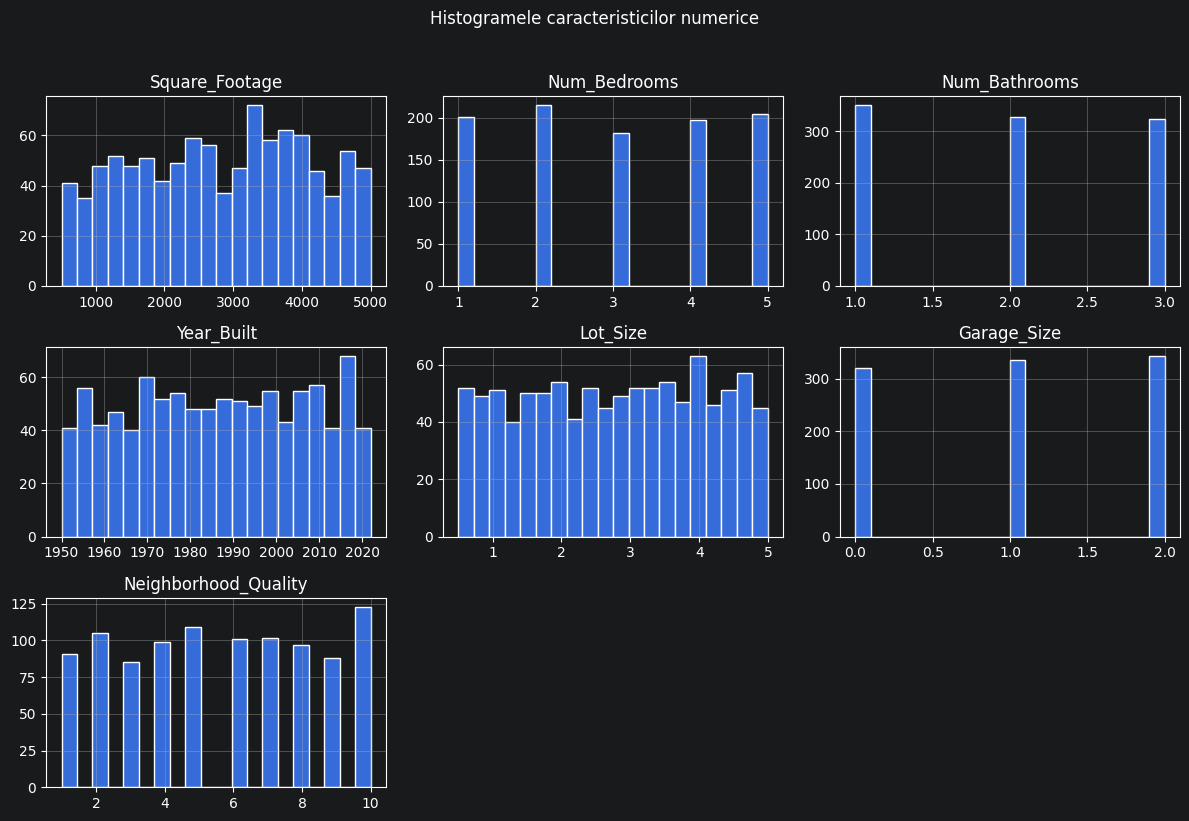

In [26]:
num_features = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']

df[num_features].hist(figsize=(12, 8), bins=20, edgecolor='white')
plt.suptitle("Histogramele caracteristicilor numerice", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Scatter plot-uri: caracteristici numerice vs preț

Scatter plot-urile ne ajută să vedem dacă există o relație liniară sau neliniară între fiecare caracteristică și preț.


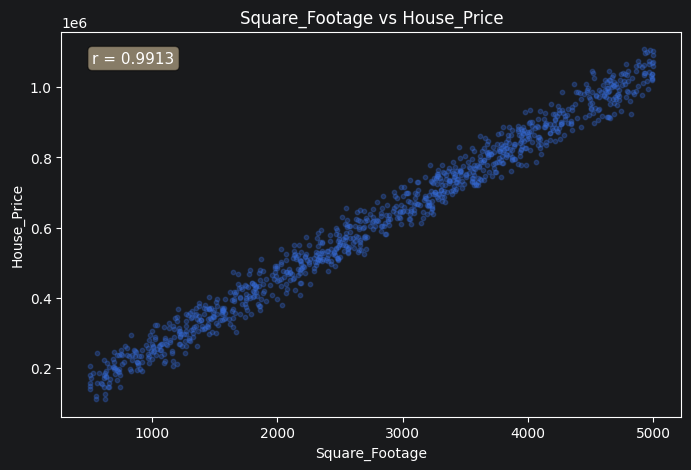

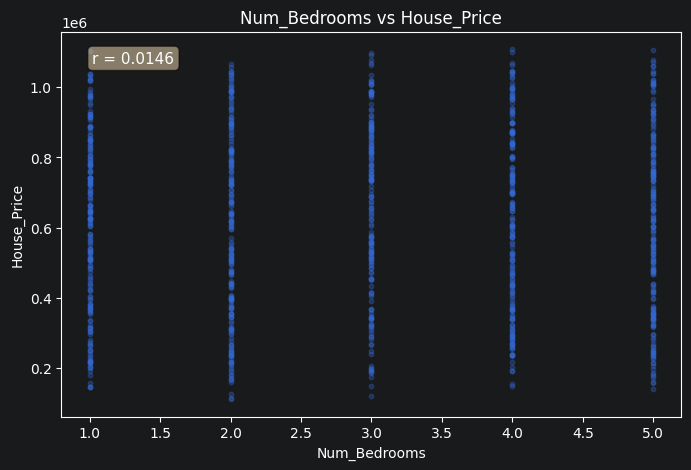

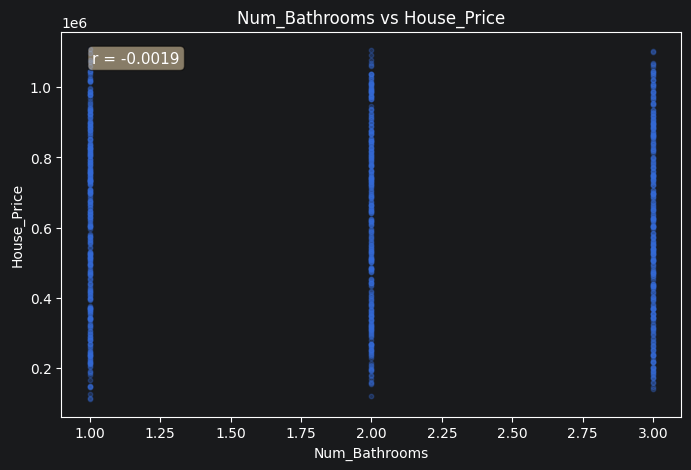

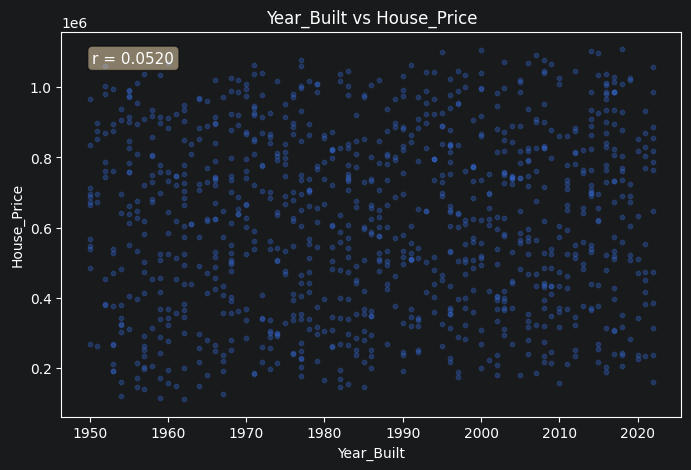

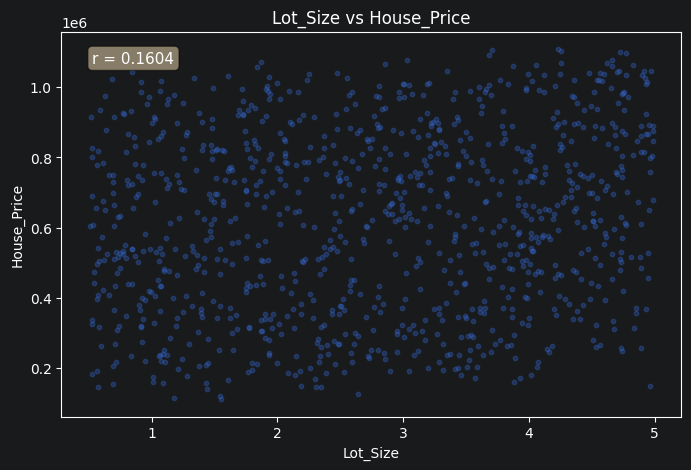

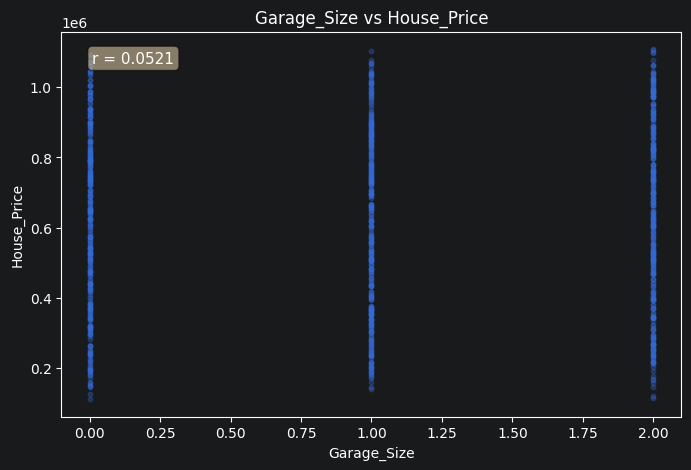

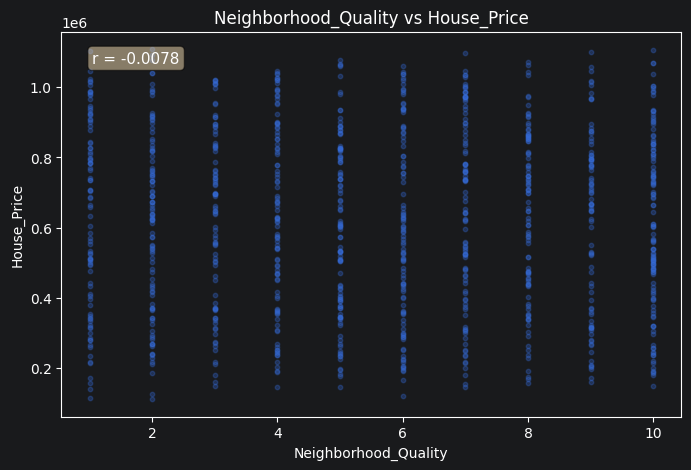

In [27]:
for col in num_features:
    plt.figure()
    plt.scatter(df[col], df['House_Price'], alpha=0.3, s=10)
    plt.title(f"{col} vs House_Price")
    plt.xlabel(col)
    plt.ylabel("House_Price")

    corr = df[col].corr(df['House_Price'])
    plt.text(0.05, 0.95, f"r = {corr:.4f}",
             transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.show()

### 4.4 Matricea de corelație

Corelația arată legătura liniară dintre variabilele numerice.
Nu este un criteriu absolut, dar ne ajută să înțelegem structura datelor.


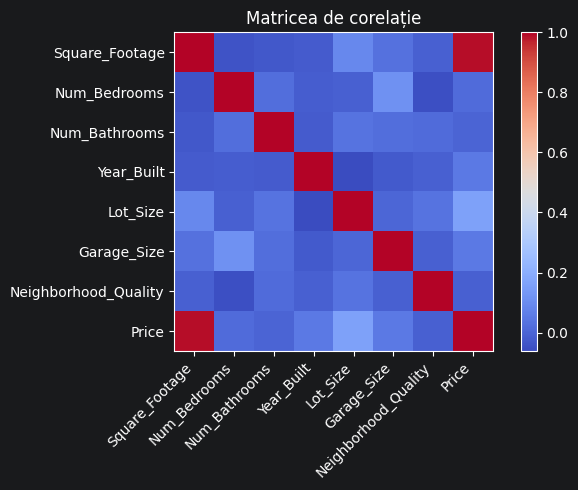

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


In [28]:
corr = df[num_features + ['House_Price']].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
labels = num_features + ['Price']
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.title("Matricea de corelație")
plt.tight_layout()
plt.show()

corr

## 5. Pregătirea datelor

Toate variabilele din dataset sunt deja numerice, deci nu este necesară codificarea categorică.

Vom:
- separa datele în train și test;
- aplica `StandardScaler` pentru modelele sensibile la scară (SVR, KNN, Gaussian Process).


In [30]:
X = df_processed.drop('House_Price', axis=1)
y = df_processed['House_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Forma X_train: {X_train.shape}")
print(f"Forma X_test: {X_test.shape}")


Forma X_train: (750, 7)
Forma X_test: (250, 7)


## 6. Antrenarea și compararea modelelor de bază

Antrenăm 9 modele cu setările implicite.
Modelele sensibile la scară (SVR, KNN, Gaussian Process) primesc datele scalate.

Metrici de evaluare:
- MSE, MAE, RMSE, R²


In [31]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'Gaussian Process': GaussianProcessRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False),
    'Explainable Boosting': ExplainableBoostingRegressor(random_state=42),
}

scaled_models = {'SVR', 'KNN', 'Gaussian Process'}

results = []

for name, model in models.items():
    if name in scaled_models:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name, 'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R²': r2
    })

    print(f"{name:25s} | R² = {r2:+.6f} | RMSE = {rmse:>12,.2f}")

print("\nToate cele 9 modele au fost antrenate.")

Linear Regression         | R² = +0.998363 | RMSE =    10,196.58
Decision Tree             | R² = +0.986677 | RMSE =    29,092.79
Random Forest             | R² = +0.993805 | RMSE =    19,837.81
SVR                       | R² = -0.020661 | RMSE =   254,639.64
KNN                       | R² = +0.893730 | RMSE =    82,165.81
Gaussian Process          | R² = +0.840067 | RMSE =   100,798.54
XGBoost                   | R² = +0.995000 | RMSE =    17,822.27
CatBoost                  | R² = +0.997145 | RMSE =    13,466.69
Explainable Boosting      | R² = +0.998115 | RMSE =    10,942.11

Toate cele 9 modele au fost antrenate.


### 6.1 Tabel comparativ

Sortăm modelele după R² pentru a vedea care au performanța cea mai bună.


In [32]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

results_df

,Model,MSE,MAE,RMSE,R²
1,Linear Regression,1.039703e+08,8170.829151,10196.583986,0.998363
2,Explainable Boosting,1.197299e+08,8855.433784,10942.114332,0.998115
3,CatBoost,1.813517e+08,10647.171681,13466.686924,0.997145
4,XGBoost,3.176332e+08,13836.703509,17822.267037,0.995000
5,Random Forest,3.935389e+08,15786.291851,19837.814219,0.993805
6,Decision Tree,8.463904e+08,23392.182412,29092.790142,0.986677
7,KNN,6.751221e+09,68729.307281,82165.811828,0.893730
8,Gaussian Process,1.016035e+10,65942.681447,100798.539347,0.840067
9,SVR,6.484134e+10,220342.489773,254639.635150,-0.020661


### 6.2 Grafic comparativ

Vizualizăm R² și RMSE pentru toate modelele.


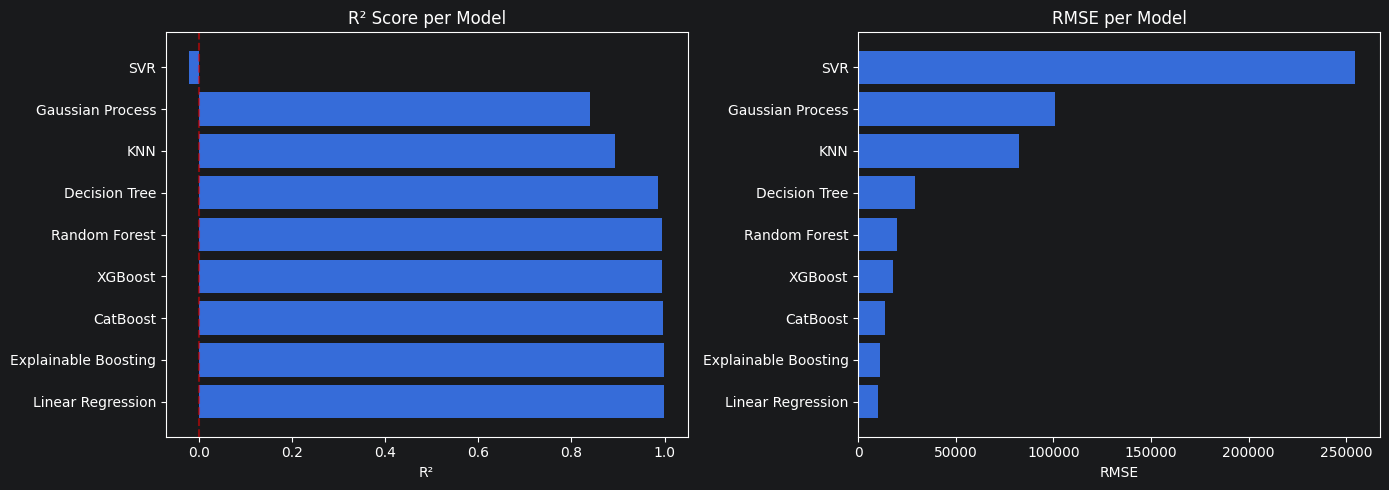

Top 5 modele selectate pentru tuning: ['Linear Regression', 'Explainable Boosting', 'CatBoost', 'XGBoost', 'Random Forest']


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['Model'], results_df['R²'])
axes[0].set_title('R² Score per Model')
axes[0].set_xlabel('R²')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

axes[1].barh(results_df['Model'], results_df['RMSE'])
axes[1].set_title('RMSE per Model')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()

top5_names = results_df.head(5)['Model'].tolist()
print("Top 5 modele selectate pentru tuning:", top5_names)

## 7. Optimizarea hiperparametrilor

Selectăm cele mai bune 5 modele și aplicăm:
- **GridSearchCV** pentru spații de căutare mici;
- **BayesSearchCV** pentru spații de căutare mari.

Cross-validation: 5-fold pe setul de antrenare.
Scoring: `neg_mean_squared_error`.


In [34]:
param_grids = {
    'Linear Regression': {
        'method': 'grid',
        'params': {
            'fit_intercept': [True, False],
        }
    },
    'Decision Tree': {
        'method': 'grid',
        'params': {
            'max_depth': [3, 5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 5, 10],
        }
    },
    'Random Forest': {
        'method': 'bayes',
        'params': {
            'n_estimators': Integer(50, 300),
            'max_depth': Integer(3, 20),
            'min_samples_split': Integer(2, 20),
            'max_features': Categorical(['sqrt', 'log2', None]),
        },
        'n_iter': 30
    },
    'SVR': {
        'method': 'bayes',
        'params': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'epsilon': Real(0.01, 1.0, prior='log-uniform'),
            'kernel': Categorical(['rbf', 'linear', 'poly']),
            'gamma': Categorical(['scale', 'auto']),
        },
        'n_iter': 30
    },
    'KNN': {
        'method': 'grid',
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski'],
        }
    },
    'Gaussian Process': {
        'method': 'grid',
        'params': {
            'alpha': [1e-10, 1e-5, 1e-2, 0.1, 1.0],
            'normalize_y': [True, False],
        }
    },
    'XGBoost': {
        'method': 'bayes',
        'params': {
            'n_estimators': Integer(50, 300),
            'max_depth': Integer(2, 10),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0),
            'colsample_bytree': Real(0.6, 1.0),
        },
        'n_iter': 30
    },
    'CatBoost': {
        'method': 'bayes',
        'params': {
            'iterations': Integer(100, 500),
            'depth': Integer(3, 8),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'l2_leaf_reg': Real(1, 10),
        },
        'n_iter': 30
    },
    'Explainable Boosting': {
        'method': 'grid',
        'params': {
            'max_bins': [128, 256, 512],
            'max_rounds': [5000, 10000],
            'learning_rate': [0.01, 0.02],
            'min_samples_leaf': [2, 5, 10],
        }
    },
}

In [35]:
tuned_results = []
best_models = {}

for model_name in top5_names:
    print(f"\n{'='*50}")
    print(f"Tuning: {model_name}")

    if model_name in scaled_models:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    base_models_init = {
        'Linear Regression': LinearRegression(),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'Random Forest': RandomForestRegressor(random_state=42),
        'SVR': SVR(),
        'KNN': KNeighborsRegressor(),
        'Gaussian Process': GaussianProcessRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42, verbosity=0),
        'CatBoost': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False),
        'Explainable Boosting': ExplainableBoostingRegressor(random_state=42),
    }

    grid_info = param_grids[model_name]
    method = grid_info['method']
    params = grid_info['params']
    base_model = base_models_init[model_name]

    if method == 'grid':
        search = GridSearchCV(
            estimator=base_model, param_grid=params,
            cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0
        )
    else:
        search = BayesSearchCV(
            estimator=base_model, search_spaces=params,
            n_iter=grid_info.get('n_iter', 30),
            cv=5, scoring='neg_mean_squared_error', n_jobs=-1,
            verbose=0, random_state=42
        )

    search.fit(Xtr, y_train)

    best_model = search.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(Xte)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    tuned_results.append({
        'Model': model_name, 'Method': method.upper(),
        'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'Best Params': search.best_params_,
    })

    print(f"  Metoda: {method.upper()}")
    print(f"  Best Params: {search.best_params_}")
    print(f"  Test R²: {r2:.6f} | RMSE: {rmse:,.2f}")

print(f"\n{'='*50}")
print("Tuning complet.")


Tuning: Linear Regression
  Metoda: GRID
  Best Params: {'fit_intercept': True}
  Test R²: 0.998363 | RMSE: 10,196.58

Tuning: Explainable Boosting
  Metoda: GRID
  Best Params: {'learning_rate': 0.02, 'max_bins': 256, 'max_rounds': 5000, 'min_samples_leaf': 10}
  Test R²: 0.997986 | RMSE: 11,310.04

Tuning: CatBoost
  Metoda: BAYES
  Best Params: OrderedDict({'depth': 4, 'iterations': 417, 'l2_leaf_reg': 1.0, 'learning_rate': 0.0358935782576249})
  Test R²: 0.997659 | RMSE: 12,194.39

Tuning: XGBoost
  Metoda: BAYES
  Best Params: OrderedDict({'colsample_bytree': 0.9504721777142331, 'learning_rate': 0.1422945766929498, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.6})
  Test R²: 0.997013 | RMSE: 13,776.38

Tuning: Random Forest
  Metoda: BAYES
  Best Params: OrderedDict({'max_depth': 15, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 300})
  Test R²: 0.993880 | RMSE: 19,718.34

Tuning complet.


### 7.1 Tabel comparativ — modele optimizate


In [36]:
tuned_df = pd.DataFrame(tuned_results)
tuned_df = tuned_df.sort_values('R²', ascending=False).reset_index(drop=True)
tuned_df.index = tuned_df.index + 1

tuned_df[['Model', 'Method', 'MSE', 'MAE', 'RMSE', 'R²']]

,Model,Method,MSE,MAE,RMSE,R²
1,Linear Regression,GRID,1.039703e+08,8170.829151,10196.583986,0.998363
2,Explainable Boosting,GRID,1.279170e+08,9022.431303,11310.040188,0.997986
3,CatBoost,BAYES,1.487033e+08,9724.043222,12194.394778,0.997659
4,XGBoost,BAYES,1.897886e+08,11179.116417,13776.379053,0.997013
5,Random Forest,BAYES,3.888129e+08,15687.510984,19718.340370,0.993880


### 7.2 Parametrii optimi


In [37]:
for _, row in tuned_df.iterrows():
    print(f"\n{row['Model']} ({row['Method']}):")
    for param, val in row['Best Params'].items():
        print(f"   {param}: {val}")


Linear Regression (GRID):
   fit_intercept: True

Explainable Boosting (GRID):
   learning_rate: 0.02
   max_bins: 256
   max_rounds: 5000
   min_samples_leaf: 10

CatBoost (BAYES):
   depth: 4
   iterations: 417
   l2_leaf_reg: 1.0
   learning_rate: 0.0358935782576249

XGBoost (BAYES):
   colsample_bytree: 0.9504721777142331
   learning_rate: 0.1422945766929498
   max_depth: 3
   n_estimators: 300
   subsample: 0.6

Random Forest (BAYES):
   max_depth: 15
   max_features: None
   min_samples_split: 2
   n_estimators: 300


### 7.3 Comparație: baseline vs tuned

Acest grafic ne ajută să vedem dacă optimizarea a adus un câștig real.


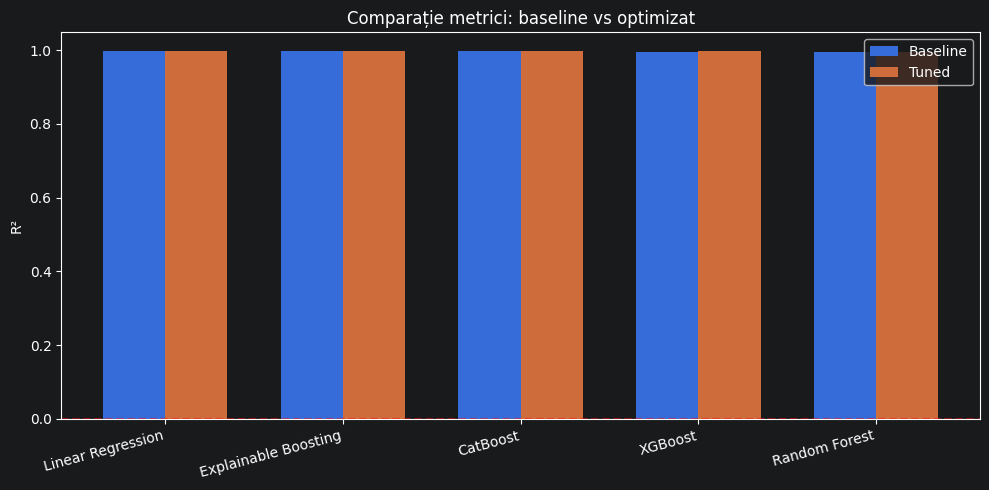

In [38]:
comparison_data = []
for _, row in tuned_df.iterrows():
    name = row['Model']
    tuned_r2 = row['R²']
    baseline_r2 = results_df[results_df['Model'] == name]['R²'].values[0]
    comparison_data.append({'Model': name, 'Baseline R²': baseline_r2, 'Tuned R²': tuned_r2})

comp_df = pd.DataFrame(comparison_data)

x = np.arange(len(comp_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, comp_df['Baseline R²'], width, label='Baseline')
plt.bar(x + width/2, comp_df['Tuned R²'], width, label='Tuned')
plt.xticks(x, comp_df['Model'], rotation=15, ha='right')
plt.ylabel('R²')
plt.title('Comparație metrici: baseline vs optimizat')
plt.legend()
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Curbele de învățare

Curbele de învățare ne ajută să diagnosticăm modelele.

Situații importante:
- dacă scorul de antrenare crește, dar scorul de validare rămâne jos, avem overfitting;
- dacă ambele sunt slabe, modelul poate fi prea simplu;
- dacă cele două curbe converg la un nivel ridicat, modelul este bun.


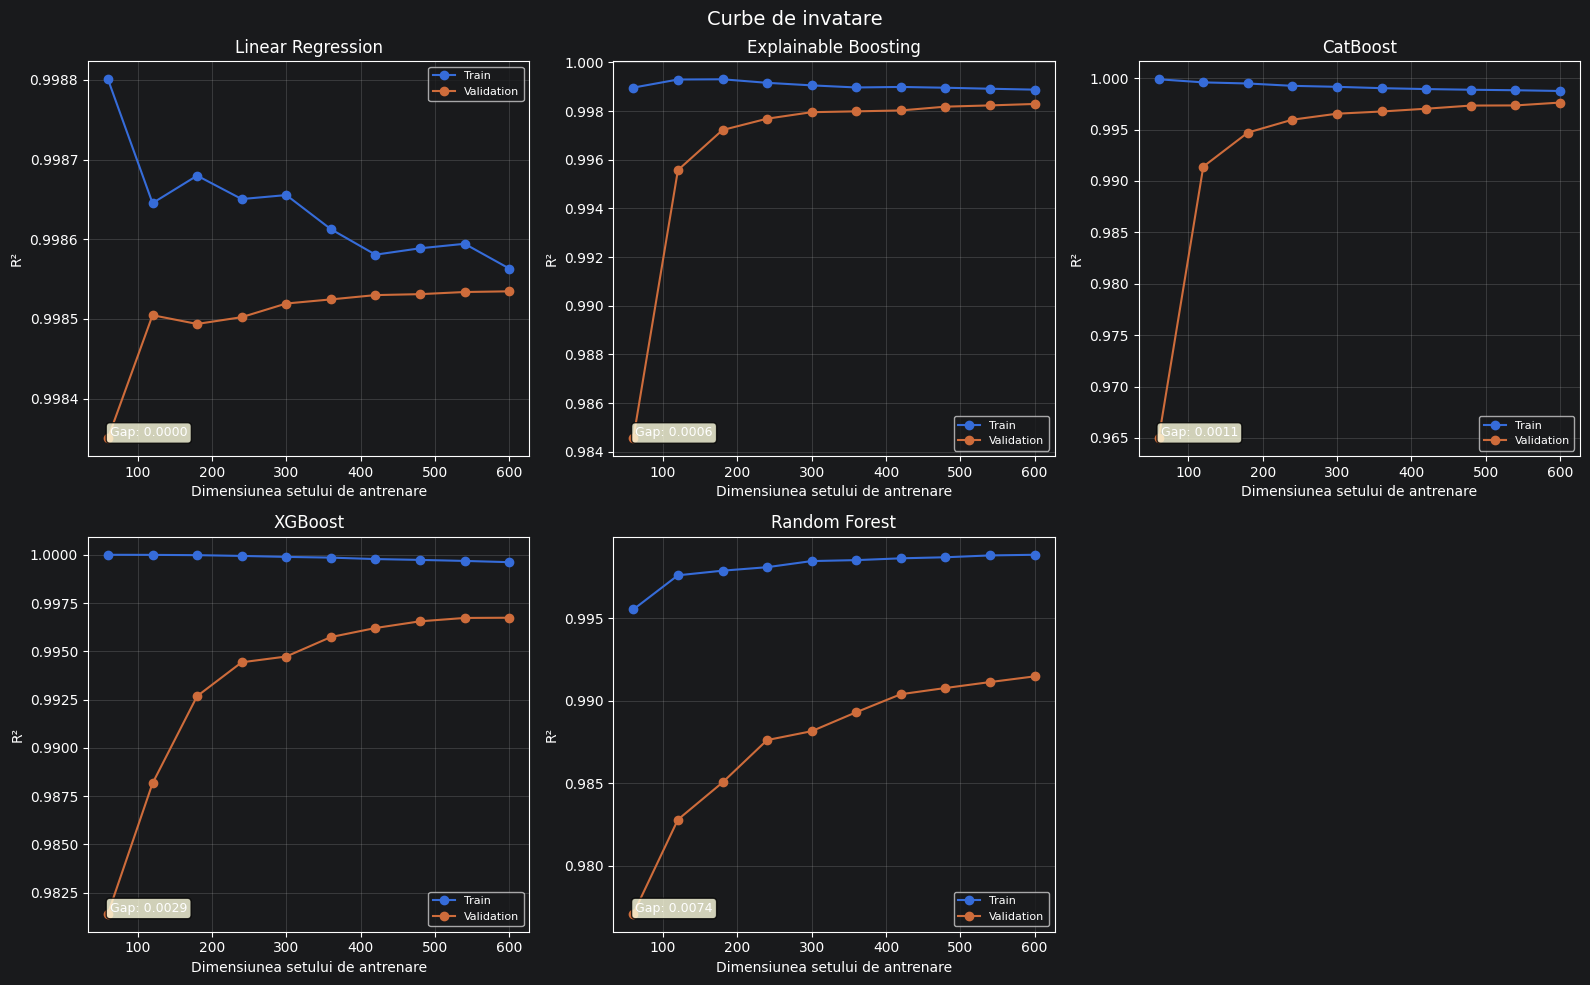

In [39]:
tuned_model_names = tuned_df.sort_values('R²', ascending=False)['Model'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, model_name in enumerate(tuned_model_names):
    ax = axes[i]

    if model_name in scaled_models:
        Xtr = X_train_scaled
    else:
        Xtr = X_train

    best_model = best_models[model_name]

    train_sizes, train_scores, val_scores = learning_curve(
        best_model, Xtr, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='r2', n_jobs=-1, random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', label='Train')
    ax.plot(train_sizes, val_mean, 'o-', label='Validation')
    ax.set_title(model_name)
    ax.set_xlabel('Dimensiunea setului de antrenare')
    ax.set_ylabel('R²')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    gap = train_mean[-1] - val_mean[-1]
    ax.text(0.05, 0.05, f'Gap: {gap:.4f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

if len(tuned_model_names) < 6:
    axes[5].set_visible(False)

plt.suptitle('Curbe de invatare', fontsize=14)
plt.tight_layout()
plt.show()


## 9. Explicabilitatea cu SHAP

SHAP (SHapley Additive exPlanations) calculează contribuția fiecărei variabile la fiecare predicție.

Vom analiza primele 3 modele din clasament:
- explicabilitate globală (summary plot, bar plot);
- explicabilitate locală (waterfall plot, force plot);
- relații de dependență (scatter plots).


In [44]:
top5_names = tuned_df.sort_values('R²', ascending=False).head(5)['Model'].tolist()
print("Top 3 modele pentru analiza SHAP:")
for i, name in enumerate(top5_names, 1):
    r2_val = tuned_df[tuned_df['Model'] == name]['R²'].values[0]
    print(f"  {i}. {name} (R² = {r2_val:.6f})")

Top 3 modele pentru analiza SHAP:
  1. Linear Regression (R² = 0.998363)
  2. Explainable Boosting (R² = 0.997986)
  3. CatBoost (R² = 0.997659)
  4. XGBoost (R² = 0.997013)
  5. Random Forest (R² = 0.993880)


### 9.1 Calculul valorilor SHAP

Folosim `TreeExplainer` pentru modele tree-based și `KernelExplainer` ca fallback.

In [45]:
def compute_shap(model, model_name, X_data):
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_data)
    except Exception:
        try:
            background = shap.sample(X_data, min(100, len(X_data)), random_state=42)
            explainer = shap.KernelExplainer(model.predict, background)
            shap_values = explainer.shap_values(X_data.iloc[:200], nsamples=100)
            X_data = X_data.iloc[:200]
        except Exception as e:
            print(f"  Nu s-a putut calcula SHAP pentru {model_name}: {e}")
            return None, None, None
    return explainer, shap_values, X_data

shap_data = {}
for model_name in top5_names:
    print(f"\nCalcul SHAP pentru: {model_name}...")

    if model_name in scaled_models:
        X_shap = X_test_scaled.copy()
    else:
        X_shap = X_test.copy()

    model = best_models[model_name]
    explainer, shap_values, X_used = compute_shap(model, model_name, X_shap)

    if explainer is not None:
        shap_data[model_name] = {
            'explainer': explainer,
            'shap_values': shap_values,
            'X_data': X_used
        }
        print(f"  SHAP calculat. Shape: {np.array(shap_values).shape}")

print(f"\nSHAP calculat pentru {len(shap_data)} modele din 3.")



Calcul SHAP pentru: Linear Regression...


  0%|          | 0/200 [00:00<?, ?it/s]

  SHAP calculat. Shape: (200, 7)

Calcul SHAP pentru: Explainable Boosting...
Provided model function fails when applied to the provided data set.
  Nu s-a putut calcula SHAP pentru Explainable Boosting: object of type 'NoneType' has no len()

Calcul SHAP pentru: CatBoost...
  SHAP calculat. Shape: (250, 7)

Calcul SHAP pentru: XGBoost...
  SHAP calculat. Shape: (250, 7)

Calcul SHAP pentru: Random Forest...
  SHAP calculat. Shape: (250, 7)

SHAP calculat pentru 4 modele din 3.


### 9.2 Interpretare globală: summary plot și bar plot

Summary plot arată distribuția impactului fiecărei variabile.
Bar plot arată importanța medie absolută (mean |SHAP|).



SHAP Global — Linear Regression


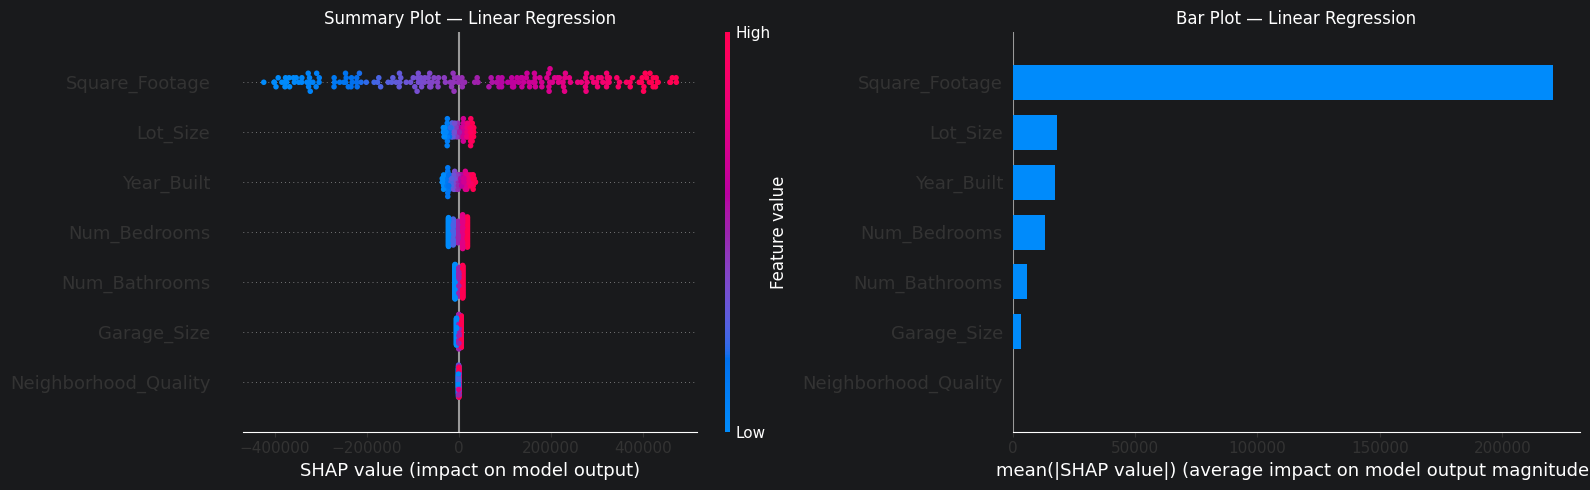


Top 3 caracteristici:
   1. Square_Footage: mean |SHAP| = 220,713.27
   2. Lot_Size: mean |SHAP| = 17,920.69
   3. Year_Built: mean |SHAP| = 17,179.37

SHAP Global — CatBoost


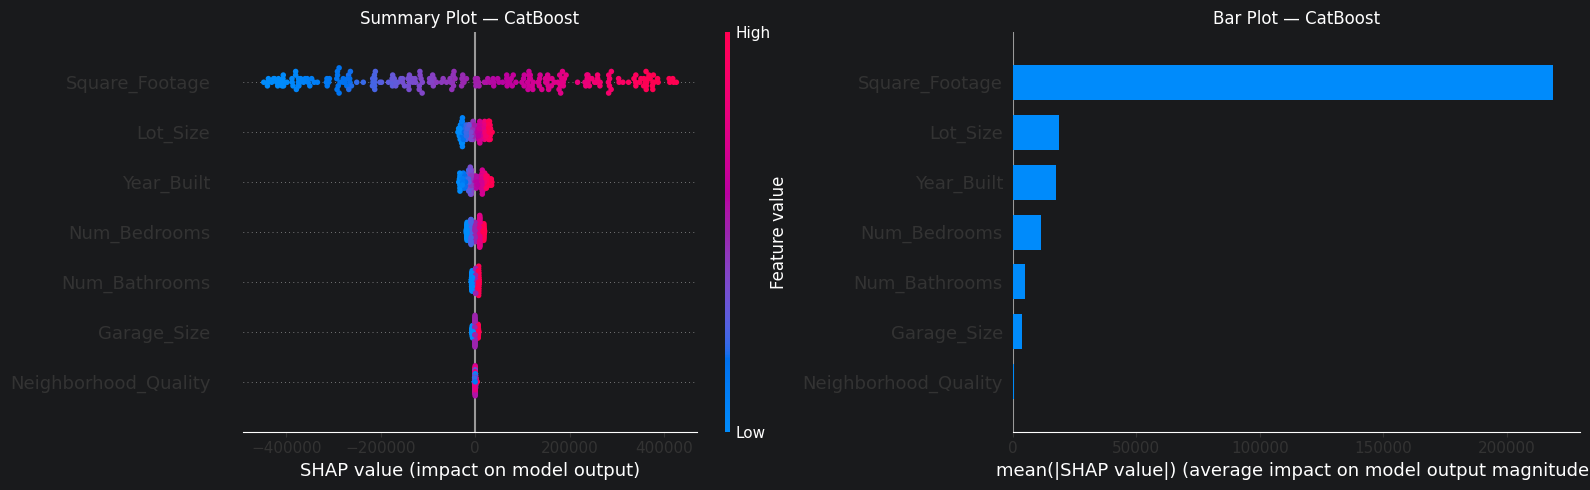


Top 3 caracteristici:
   1. Square_Footage: mean |SHAP| = 218,607.52
   2. Lot_Size: mean |SHAP| = 18,734.62
   3. Year_Built: mean |SHAP| = 17,374.42

SHAP Global — XGBoost


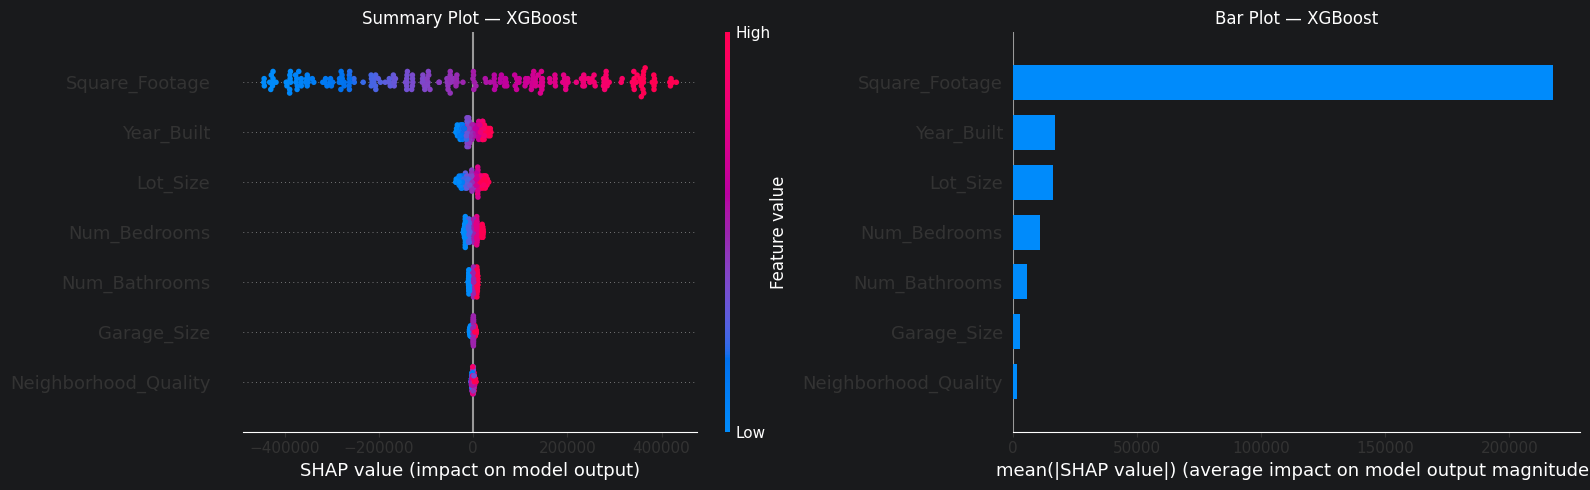


Top 3 caracteristici:
   1. Square_Footage: mean |SHAP| = 217,523.50
   2. Year_Built: mean |SHAP| = 17,082.23
   3. Lot_Size: mean |SHAP| = 16,118.32

SHAP Global — Random Forest


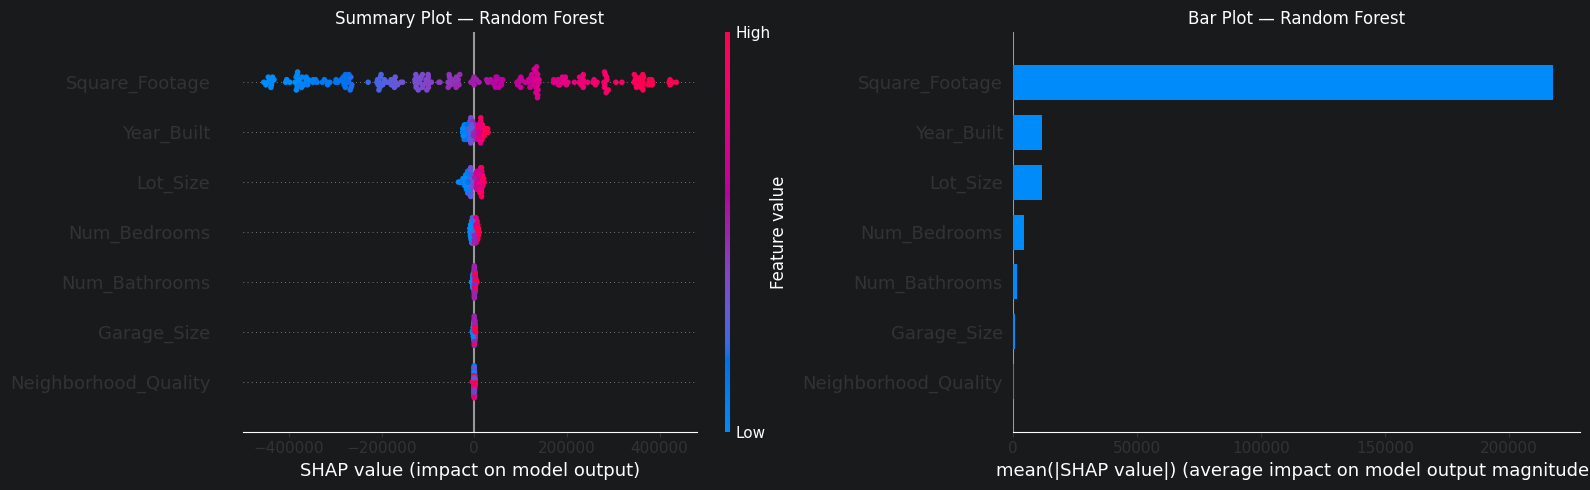


Top 3 caracteristici:
   1. Square_Footage: mean |SHAP| = 217,631.25
   2. Year_Built: mean |SHAP| = 11,951.01
   3. Lot_Size: mean |SHAP| = 11,867.41


In [46]:
for model_name, data in shap_data.items():
    sv = data['shap_values']
    X_d = data['X_data']

    print(f"\n{'='*50}")
    print(f"SHAP Global — {model_name}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    plt.sca(axes[0])
    shap.summary_plot(sv, X_d, show=False, plot_size=None)
    axes[0].set_title(f'Summary Plot — {model_name}')

    plt.sca(axes[1])
    shap.summary_plot(sv, X_d, plot_type='bar', show=False, plot_size=None)
    axes[1].set_title(f'Bar Plot — {model_name}')

    plt.tight_layout()
    plt.show()

    mean_abs_shap = np.abs(sv).mean(axis=0)
    feature_importance = pd.Series(mean_abs_shap, index=X_d.columns).sort_values(ascending=False)
    print("\nTop 3 caracteristici:")
    for j, (feat, imp) in enumerate(feature_importance.head(3).items(), 1):
        print(f"   {j}. {feat}: mean |SHAP| = {imp:,.2f}")


### 9.3 Interpretare locală: waterfall plot și force plot

Analiza locală explică o predicție individuală: ce variabile au contribuit și în ce sens.



SHAP Local — Linear Regression
  Pret real: 901,000.49
  Pret prezis: 869,058.38
  Eroare: 31,942.10


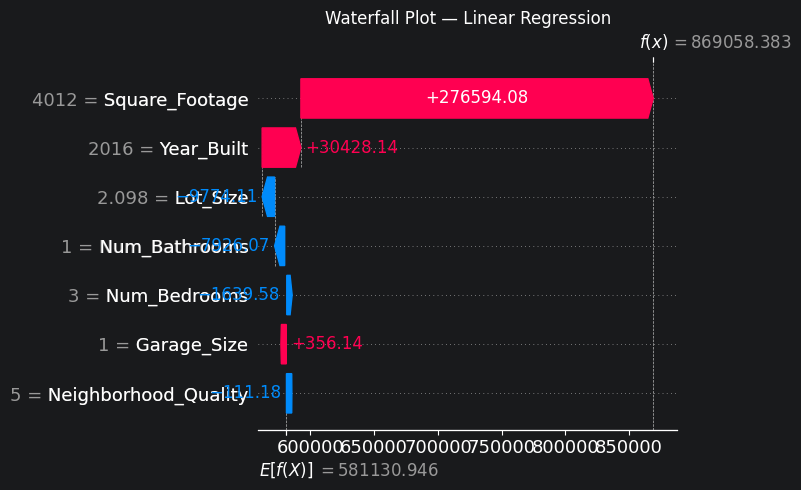

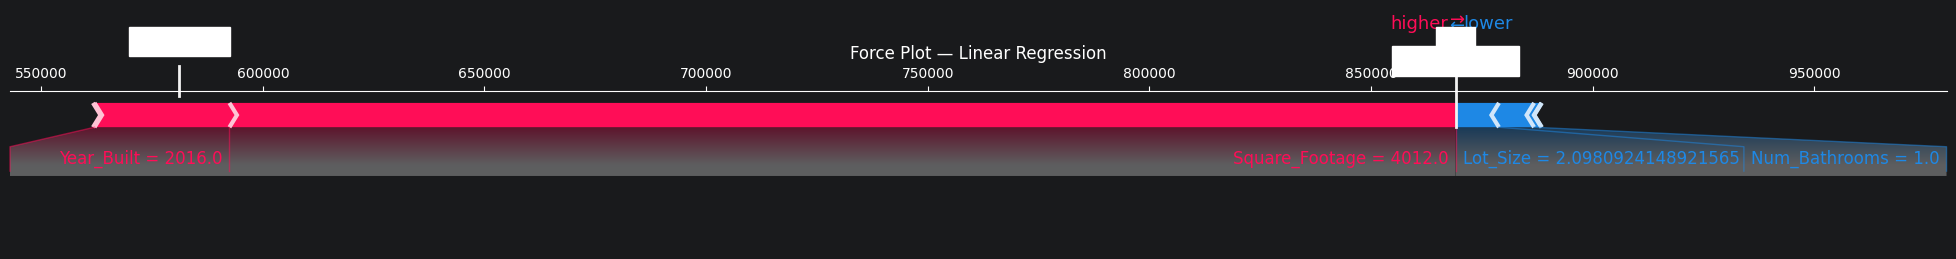


SHAP Local — CatBoost
  Pret real: 901,000.49
  Pret prezis: 869,337.21
  Eroare: 31,663.28


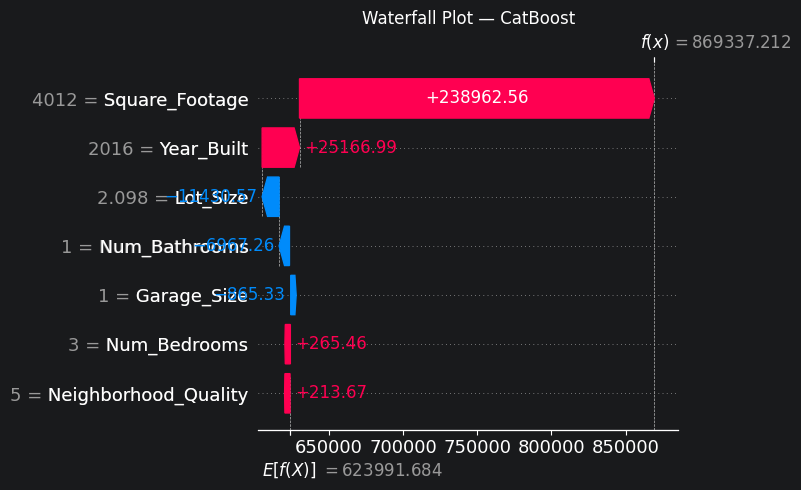

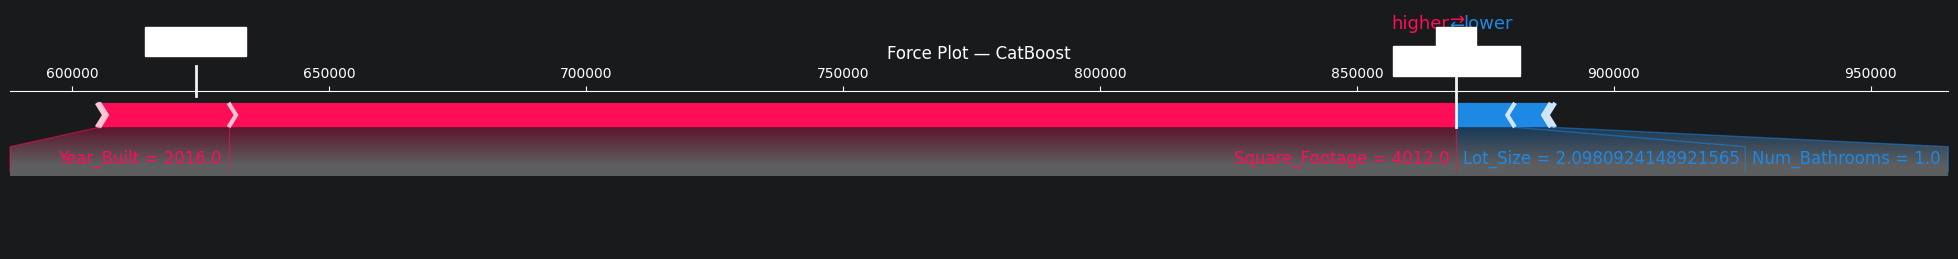


SHAP Local — XGBoost
  Pret real: 901,000.49
  Pret prezis: 864,138.06
  Eroare: 36,862.43


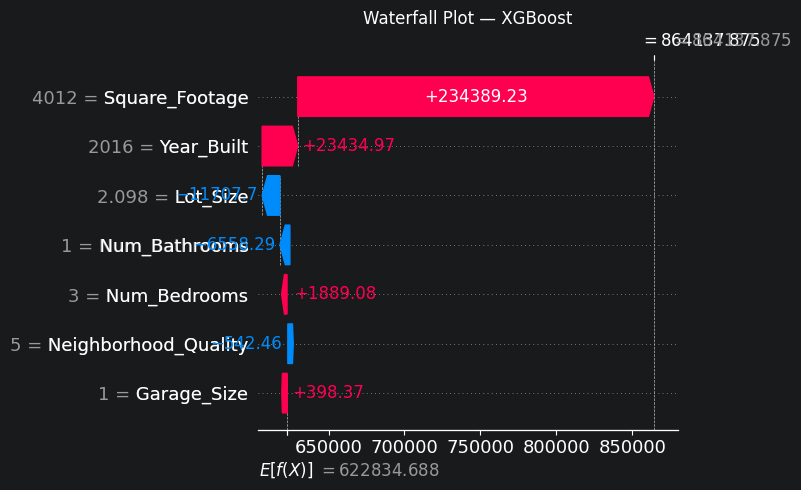

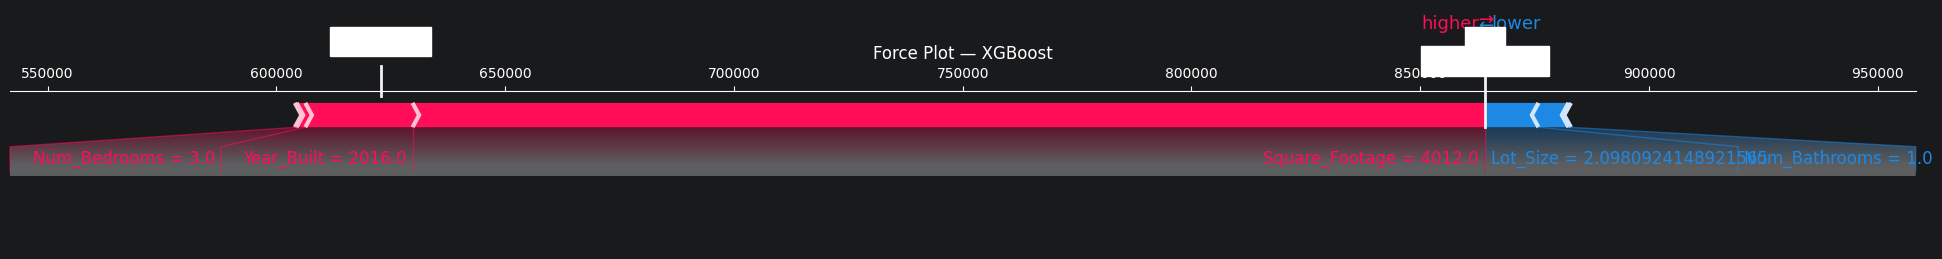


SHAP Local — Random Forest
  Pret real: 901,000.49
  Pret prezis: 852,394.64
  Eroare: 48,605.84


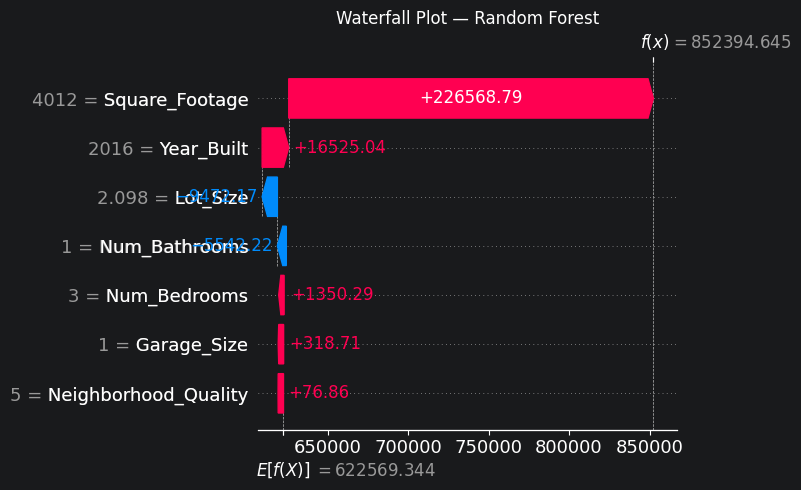

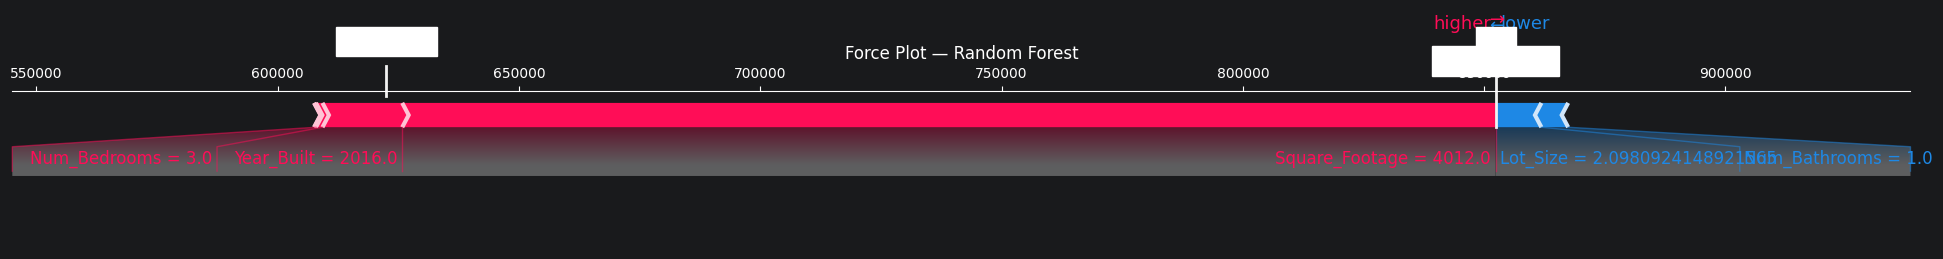

In [47]:
for model_name, data in shap_data.items():
    sv = data['shap_values']
    X_d = data['X_data']
    explainer = data['explainer']

    print(f"\n{'='*50}")
    print(f"SHAP Local — {model_name}")

    idx = 0
    actual_price = y_test.iloc[idx]
    predicted_price = best_models[model_name].predict(X_d.iloc[[idx]])[0]

    print(f"  Pret real: {actual_price:,.2f}")
    print(f"  Pret prezis: {predicted_price:,.2f}")
    print(f"  Eroare: {abs(actual_price - predicted_price):,.2f}")

    try:
        if hasattr(explainer, 'expected_value'):
            base_val = explainer.expected_value
            if isinstance(base_val, np.ndarray):
                base_val = base_val[0]
        else:
            base_val = np.mean(sv)

        explanation = shap.Explanation(
            values=sv[idx],
            base_values=base_val,
            data=X_d.iloc[idx].values,
            feature_names=list(X_d.columns)
        )

        plt.figure(figsize=(10, 5))
        shap.waterfall_plot(explanation, show=False)
        plt.title(f'Waterfall Plot — {model_name}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  Waterfall plot error: {e}")

    try:
        shap.initjs()
        shap.force_plot(base_val, sv[idx], X_d.iloc[idx], matplotlib=True, show=False)
        plt.title(f'Force Plot — {model_name}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  Force plot error: {e}")


### 9.4 Relații de dependență: scatter plots

Scatter plot-urile SHAP arată relația dintre valoarea unei variabile și impactul ei asupra predicției.



SHAP Scatter Plots — Linear Regression


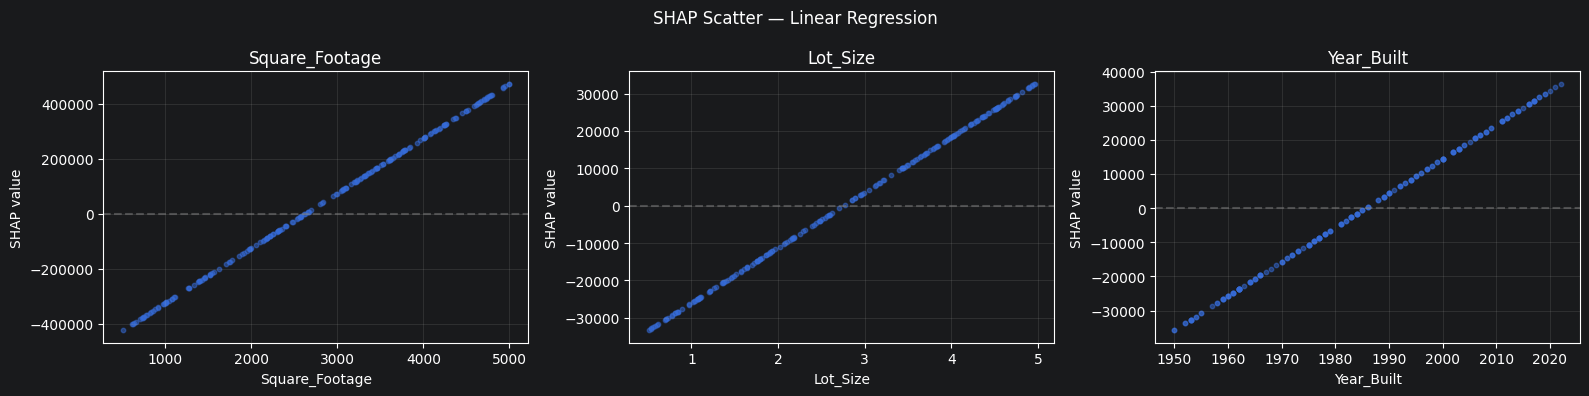


SHAP Scatter Plots — CatBoost


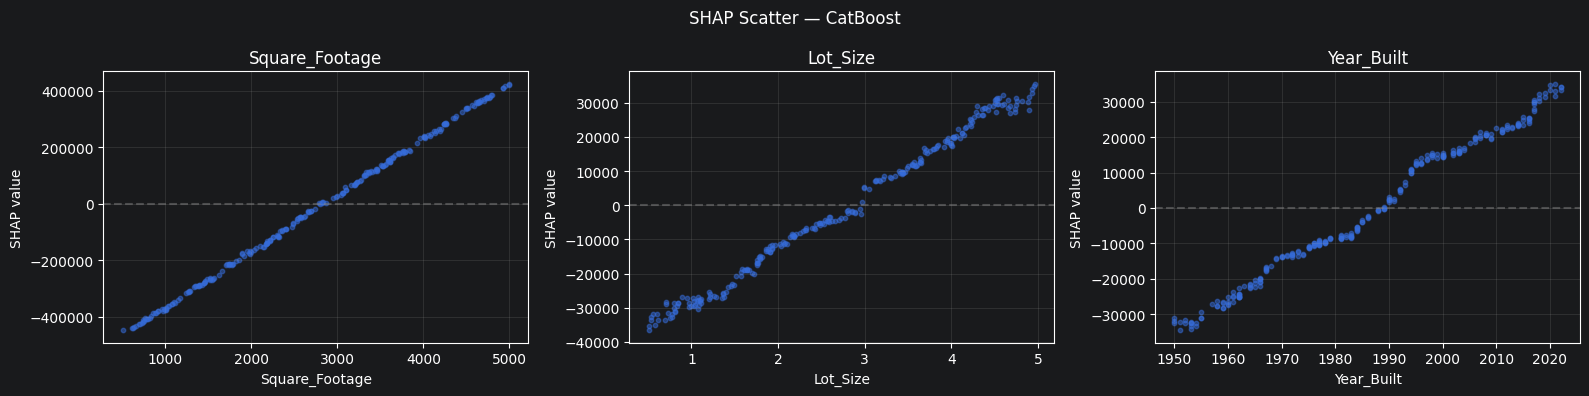


SHAP Scatter Plots — XGBoost


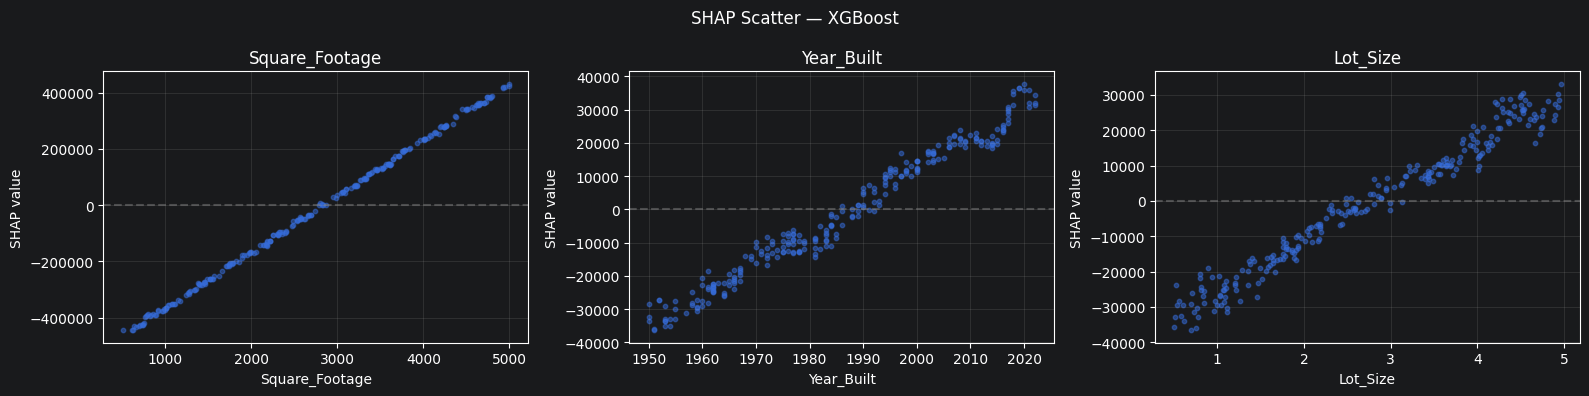


SHAP Scatter Plots — Random Forest


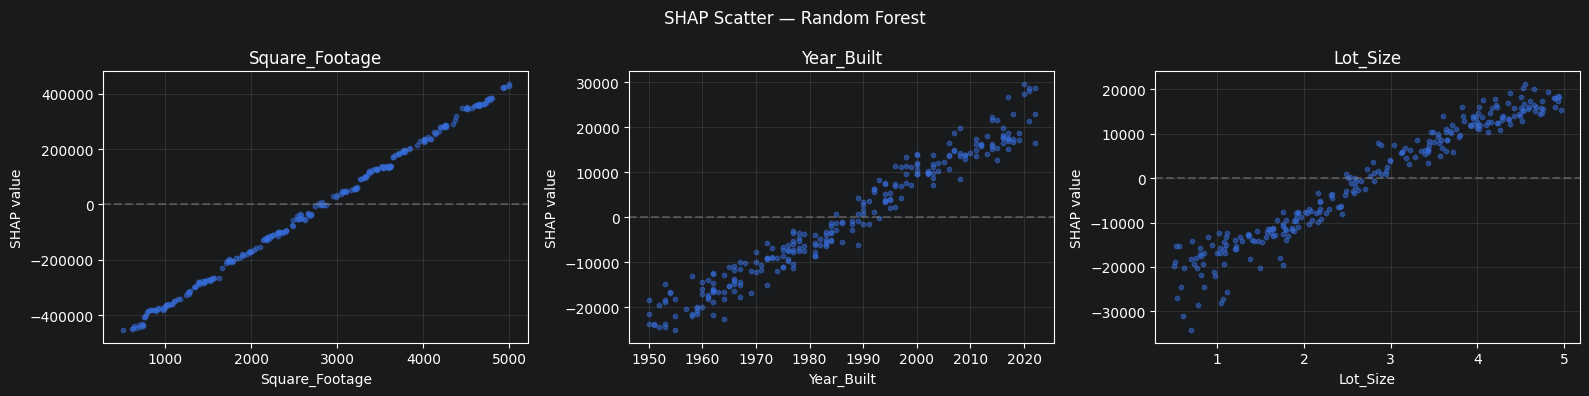

In [48]:
for model_name, data in shap_data.items():
    sv = data['shap_values']
    X_d = data['X_data']

    print(f"\n{'='*50}")
    print(f"SHAP Scatter Plots — {model_name}")

    mean_abs = np.abs(sv).mean(axis=0)
    top_feat_idx = np.argsort(mean_abs)[::-1][:3]
    top_feat_names = [X_d.columns[i] for i in top_feat_idx]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for j, feat_name in enumerate(top_feat_names):
        feat_idx = list(X_d.columns).index(feat_name)
        ax = axes[j]

        ax.scatter(X_d[feat_name], sv[:, feat_idx], alpha=0.5, s=10)
        ax.set_xlabel(feat_name)
        ax.set_ylabel(f'SHAP value')
        ax.set_title(feat_name)
        ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.2)

    plt.suptitle(f'SHAP Scatter — {model_name}')
    plt.tight_layout()
    plt.show()